In [13]:
#Load packages
options(warn=-1)
library(scRNAseq)
library(dplyr)
library(Seurat)
library(tidyverse)
library(data.table)
library(SeuratData)
library(SeuratDisk)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQR

In [4]:
# read expression data (every experiment)
K1B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/111_CellRanger_analysis.freeze01/K1B/GEX/outs/raw_feature_bc_matrix/")) %>%
  CreateSeuratObject(project = "K1B", min.cells = 3, min.features = 200) 


K2B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/111_CellRanger_analysis.freeze01/K2B/GEX/outs/raw_feature_bc_matrix/")) %>%
  CreateSeuratObject(project = "K2B", min.cells = 3, min.features = 200) 

K3B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/111_CellRanger_analysis.freeze01/K3B/GEX/outs/raw_feature_bc_matrix/")) %>%
  CreateSeuratObject(project = "K3B", min.cells = 3, min.features = 200) 

In [5]:
# # compbined the 3 experiments
sce <- merge(K1B, y = c(K2B, K3B), add.cell.ids = c("K1B", "K2B", "K3B"), project = "FL")
sce

An object of class Seurat 
18007 features across 28357 samples within 1 assay 
Active assay: RNA (18007 features, 0 variable features)

In [6]:
# # read expression data (every experiment)
# K1B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/111_CellRanger_analysis.freeze01/K1B/GEX/outs/raw_feature_bc_matrix/")) %>%
#   CreateSeuratObject(project = "K1B", min.cells = 3, min.features = 200) 

In [7]:
#sce <- K1B

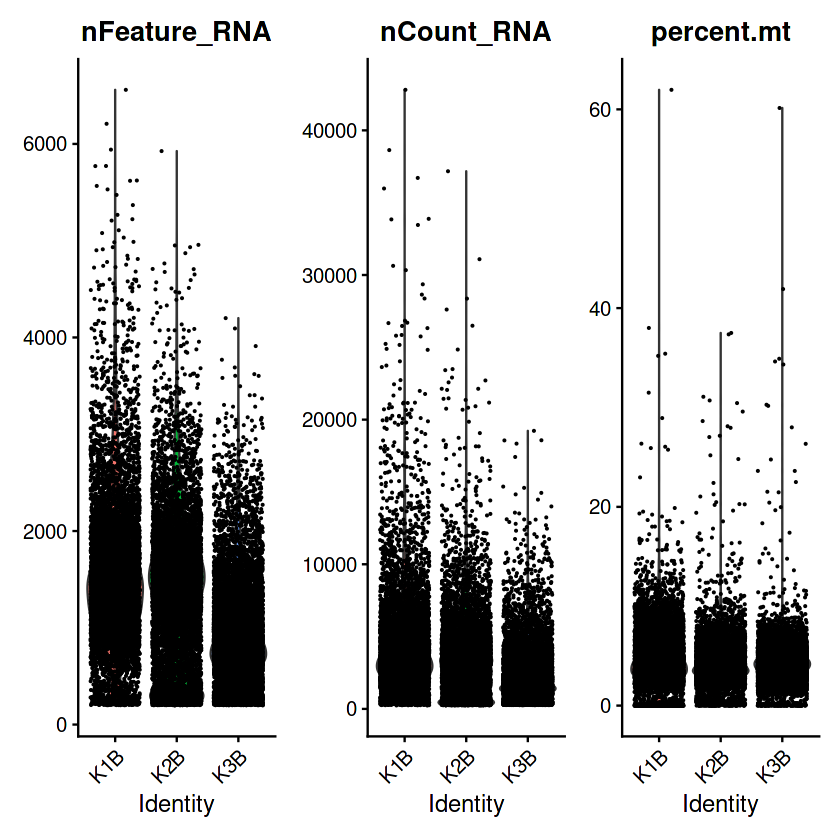

In [8]:
## Quality control:
# The [[ operator can add columns to object metadata. This is a great place to stash QC stats
sce[["percent.mt"]] <- PercentageFeatureSet(sce, pattern = "^MT-")

# Visualize QC metrics as a violin plot
VlnPlot(sce, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

In [9]:
# Normalization:
sce <- NormalizeData(sce)

When using repel, set xnudge and ynudge to 0 for optimal results



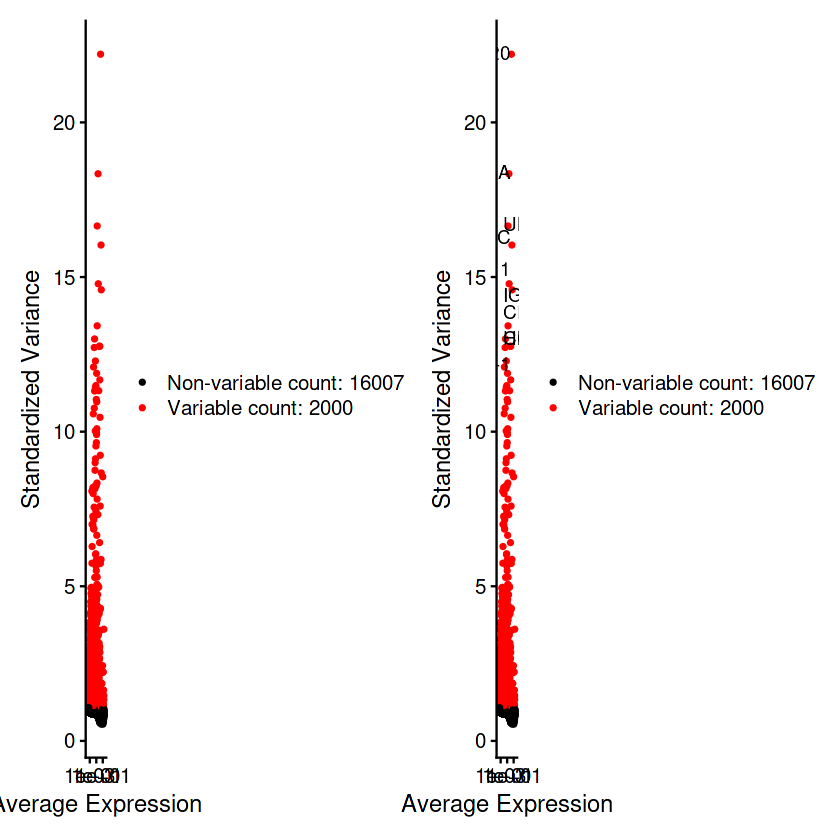

In [10]:
#Identification of highly variable features (feature selection)

sce <- FindVariableFeatures(sce, selection.method = "vst", nfeatures = 2000)

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(sce), 10)

# plot variable features with and without labels
plot1 <- VariableFeaturePlot(sce)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1 + plot2

In [11]:
# Scaling the data

all.genes <- rownames(sce)
sce <- ScaleData(sce, features = all.genes)

Centering and scaling data matrix



In [12]:
# Dimensionality reduction:
sce <- RunPCA(sce, features = VariableFeatures(object = sce))

PC_ 1 
Positive:  MKI67, UBE2C, CDKN3, CENPF, AURKB, TOP2A, GTSE1, CENPA, CDCA3, BIRC5 
	   ASPM, TPX2, PLK1, NUSAP1, CCNB2, CDCA8, CDC20, CKS2, CCNA2, HMMR 
	   TYMS, PTTG1, KIFC1, HMGB2, DLGAP5, TROAP, CDK1, CENPE, CKAP2L, UBE2S 
Negative:  IGHV3-48, IGLV2-8, MTRNR2L8, MTRNR2L12, FCMR, IGKV1D-39, IGKV1-39, IGLV3-19, EMP3, COL6A3 
	   JUN, IGHM, JCHAIN, S100A6, IGLV2-14, IGKV1D-8, APOD, FCER2, IGHV3-64D, AL138963.3 
	   ACSM3, CCR6, SELL, IGHV4-34, LY6E, S1PR1, IGHV3-49, CXCL13, IGLC2, AL139020.1 
PC_ 2 
Positive:  UBE2C, MKI67, CENPF, CDC20, PLK1, BIRC5, TOP2A, ASPM, CENPA, AURKB 
	   CDCA3, CCNB2, GTSE1, CDCA8, CCNA2, CDKN3, DLGAP5, TPX2, KIFC1, TYMS 
	   NUSAP1, TROAP, HMMR, KIF14, CKAP2L, CDK1, HJURP, CENPE, CEP55, KIF2C 
Negative:  PRPSAP2, KCNMA1, DNER, C7orf50, LMO2, AC023590.1, AC004130.1, MAP2, MT-ND3, MARCKSL1 
	   HLA-DQB1, CD22, RPS29, GMDS, MAP1B, HLA-DQA1, PPDPF, RASL11A, SSTR2, FTL 
	   MT-ND2, MYO1E, RPL38, RPS21, MFHAS1, BAIAP2L1, TCEA1, CR1L, ODC1, TOX 
PC_ 3 
Positi

In [13]:
#Determine the ‘dimensionality’ of the dataset

# NOTE: This process can take a long time for big datasets, comment out for expediency. More
# approximate techniques such as those implemented in ElbowPlot() can be used to reduce
# computation time
#sce <- JackStraw(sce, num.replicate = 100)
#sce <- ScoreJackStraw(sce, dims = 1:20)

In [14]:
#JackStrawPlot(sce, dims = 1:20)

In [15]:
#ElbowPlot(sce)

### Cluster the cells

In [16]:
sce <- FindNeighbors(sce, dims = 1:30)
sce <- FindClusters(sce)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 28357
Number of edges: 1130971

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9420
Number of communities: 25
Elapsed time: 7 seconds


In [17]:
# Run non-linear dimensional reduction (UMAP/tSNE)
sce <- RunUMAP(sce, dims = 1:10)

11:10:23 UMAP embedding parameters a = 0.9922 b = 1.112

11:10:23 Read 28357 rows and found 10 numeric columns

11:10:23 Using Annoy for neighbor search, n_neighbors = 30

11:10:23 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:10:29 Writing NN index file to temp file /tmp/RtmpdBySw6/file60b82128f556c

11:10:29 Searching Annoy index using 1 thread, search_k = 3000

11:10:48 Annoy recall = 100%

11:10:49 Commencing smooth kNN distance calibration using 1 thread

11:10:52 Initializing from normalized Laplacian + noise

11:10:54 Commencing optimization for 200 epochs, with 1187092 positive edges

11:11:14 Optimization finished



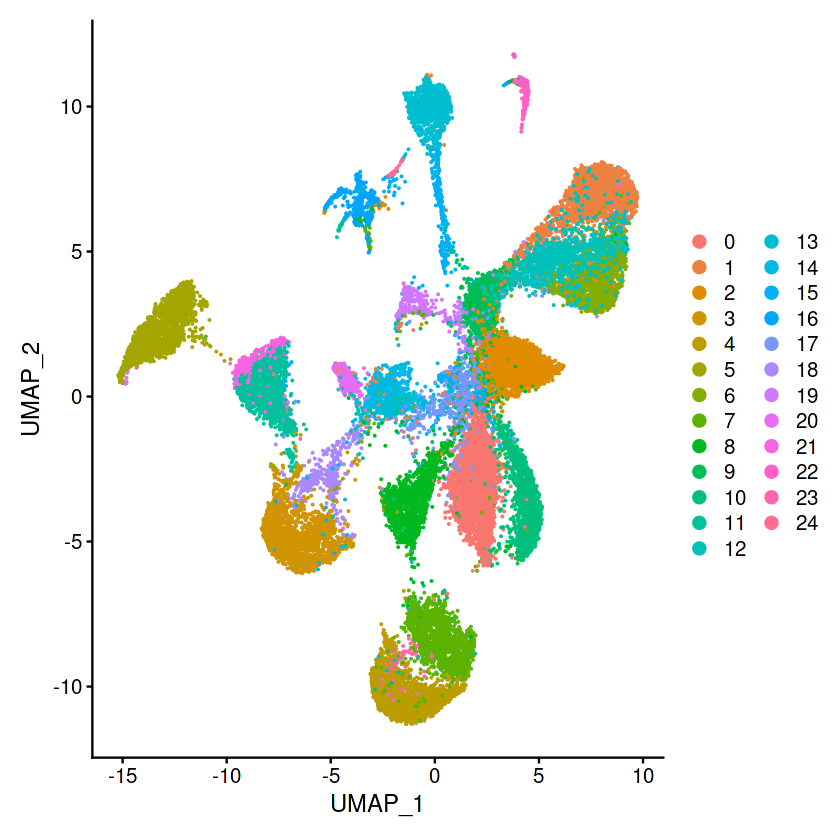

In [18]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
DimPlot(sce, reduction = "umap")

In [19]:
sce

An object of class Seurat 
18007 features across 28357 samples within 1 assay 
Active assay: RNA (18007 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [20]:
# sample sheet, get subject IDs
subjects <-
  readxl::read_excel("~/repositories/FL_10X_2/005_Sample_sheet/All_sheets.xlsx", sheet = "experimentTable") %>% 
  filter( chip %in% c( "K1B", "K2B", "K3B" ),
          analysis == "GEX",
          subject != "S2698",
          subject != "S1502" ) %>% 
  arrange( subject )

In [21]:
subjects

experimentId,subject,sample,chip,analysis,LGTCquote,LGTCquoteDate,LGTCrunDate,type,WESproject_id,WESproject_tumor,WESproject_normal
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
X005,S10000,Sa1095790,K1B,GEX,201800884,2018-02-26,2018-03-15,pool,NA,NA,NA
X007,S10971,Sa1093010,K1B,GEX,201800884,2018-02-26,2018-03-15,pool,NA,NA,NA
X011,S11770,Sa1138890,K2B,GEX,201801945,2018-04-30,2018-04-30,pool,NA,NA,NA
X013,S12118,Sa1226110,K2B,GEX,201801945,2018-04-30,2018-04-30,pool,NA,NA,NA
X009,S12282,Sa1229610,K1B,GEX,201800884,2018-02-26,2018-03-15,pool,NA,NA,NA
X045,S12390,Sa1366690,K3B,GEX,201904741,2020-03-20,2020-02-20,pool,NA,NA,NA
X017,S12500,Sa1246220,K2B,GEX,201801945,2018-04-30,2018-04-30,pool,NA,NA,NA
X043,S12500,Sa1318210,K3B,GEX,201904741,2020-03-20,2020-02-20,pool,NA,NA,NA
X015,S13530,Sa1309520,K2B,GEX,201801945,2018-04-30,2018-04-30,pool,NA,NA,NA


In [22]:
#install.packages("data.table")

In [23]:
# read cell subject assignment
cellSubject <-
    readr::read_csv( "~/repositories/FL_10X_2/182_SCSM_subjects/outs/FL_10X.SCSM_fit.ss.tsv" ) %>% 
    dplyr::rename( cell = c,
                   subject = calledS ) %>% 
  filter( !p %like% "n",
          !subject %in% c( "doublet", "SID11", "SID12", "unassigned" ) ) %>% 
  # fix difference cell
  mutate( cellSCSM = cell,
          cell = paste0( substr( cell, 5, 100 ), "_", substr( cell, 2, 2 ) ) ) %>% 
  dplyr::rename( source = p )  %>%
  mutate(cell= gsub('.{4}$', '', cell))
  cellSubject[ which (cellSubject$subject == "SID14" ), "subject" ] <-
    "S15629"

Rows: 36708 Columns: 6
── Column specification ──────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (4): p, c, calledS, status
lgl (2): isSinglet, isDoublet

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [24]:
cellSubject

source,cell,subject,status,isSinglet,isDoublet,cellSCSM
<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>
K1B,AAACCTGAGATCACGG,S10971,singlet,TRUE,FALSE,K1B:AAACCTGAGATCACGG-1
K1B,AAACCTGAGCCAGTTT,S144,singlet,TRUE,FALSE,K1B:AAACCTGAGCCAGTTT-1
K1B,AAACCTGAGGCATGTG,S144,singlet,TRUE,FALSE,K1B:AAACCTGAGGCATGTG-1
K1B,AAACCTGAGTGTTTGC,S10000,singlet,TRUE,FALSE,K1B:AAACCTGAGTGTTTGC-1
K1B,AAACCTGCAACTGCTA,S10971,singlet,TRUE,FALSE,K1B:AAACCTGCAACTGCTA-1
K1B,AAACCTGCACCACCAG,S8934,singlet,TRUE,FALSE,K1B:AAACCTGCACCACCAG-1
K1B,AAACCTGCATGCCACG,S10971,singlet,TRUE,FALSE,K1B:AAACCTGCATGCCACG-1
K1B,AAACCTGCATTTCAGG,S10971,singlet,TRUE,FALSE,K1B:AAACCTGCATTTCAGG-1
K1B,AAACCTGGTAGAAAGG,S8934,singlet,TRUE,FALSE,K1B:AAACCTGGTAGAAAGG-1


In [25]:
sce$cellSCSM

ERROR: Error: Cannot find 'cellSCSM' in this Seurat object


In [ ]:
# add subject ID into the sObject
sce <-
  AddMetaData(object = sce,
              metadata = cellSubject %>% 
                column_to_rownames( "cell" ) )

In [ ]:
#setup
colPal <-
  c( "dodgerblue2", "#E31A1C", # red
     "green4",
     "#6A3D9A", # purple
     "#FF7F00", # orange
     "gold1",
     "skyblue2", "#FB9A99", # lt pink
     "palegreen2",
     "#CAB2D6", # lt purple
     "#FDBF6F", # lt orange
     "khaki2",
     "maroon", "orchid1", "deeppink1", "blue1", "steelblue4",
     "darkturquoise", "green1", "yellow4", "yellow3",
     "darkorange4", "brown" )

seqDom <- function( d ){
  # select dominant V-gene, d = clonotypes
  return(
    d %>%
      # use v_geneKB as reference
      select( v_gene,seq ) %>%
      # add sequence length
      mutate( seqLen = nchar( seq ) ) %>% 
      group_by( seq ) %>% 
      mutate( count = row_number() ) %>% 
      ungroup() %>%
      arrange( desc( count ) ) %>% 
      # keep the top row
      top_n(1) ) }

CtypeGen <- function( v ){
  # a basic function to create clonotype ID's of a vector of sequences
  return( v %>%
            as.data.frame() %>%
            dplyr::rename( seq = "." ) %>%
            # add cellCount: to find number of rows with identical seq
            add_count( seq, name = "countInMerge" ) %>%
            # keep unique
            distinct( seq, .keep_all = TRUE ) %>% 
            # name
            arrange( desc( countInMerge ) ) %>%
            rownames_to_column( var = "cloneInMerge" ) %>% 
            mutate( cloneInMerge = as.numeric( cloneInMerge ) ) ) }


In [ ]:
#run per-subject PCA UMAP and clustering

# cluster per experiment-subject, use experiment that had SCTransform and Integration in Step 1
sceClustered <-
  mclapply( subjects %>% 
              arrange( chip, subject ) %>% 
              mutate( row = paste( chip, subject,sep = "_" ) ) %>% 
              pull( row ),
            function( x ){
              chip <-
                substr( x, 1 ,3 )
              subjID <-
                substr( x, 5, 100 )
              
              d <-
                subset( sObject, cells = sce@meta.data %>%
                              rownames_to_column( var = "cell" ) %>%
                              filter( sce@meta.data$subject == subjID,
                                      sce@meta.data$source  == chip ) %>%
                              pull( cell ) ) %>%
                RunPCA( assay = "integrated", verbose = FALSE ) %>% 
                RunUMAP( reduction = "pca", dims = 1:30, verbose = FALSE ) %>% 
                FindNeighbors( dims = 1:30, verbose = FALSE ) %>% 
                FindClusters( verbose = FALSE ) },
            mc.cores = nrow( subjects ) )


In [ ]:
# lapply( sceClustered,
#         function( x ){
          
#           subject <-
#             x@meta.data$subject %>% 
#             unique()
#           source <-
#             x@meta.data$source %>% 
#             unique()
          
#           x <-
#             left_join( left_join( x@meta.data %>%
#                                     rownames_to_column( var = "cell" ) %>%
#                                     select( - subject ),
#                                   x@reductions[[ "umap" ]]@cell.embeddings %>% 
#                                     as.data.frame() %>% 
#                                     rownames_to_column( var = "cell" ),
#                                   by = "cell" ),
#                        clones %>% 
#                          drop_na( clone ) %>% 
#                          select( -source, -status, -isSinglet, -isDoublet  ),
#                        by = "cell" )

#           # familiar colors for clusters
#           clusterIDs <-
#             x$seurat_clusters %>%
#             levels()
#           nClusterIDs <-
#             length( clusterIDs )
#           # set the colors for clusters
#           colorsClusterIDs <-
#             colPal[ c( 1 : nClusterIDs) ]
#           # names for colors
#           names( colorsClusterIDs )<-
#             clusterIDs
          
#           # overlay
#           gridExtra::grid.arrange(
#             # all cells
#             ggplot( x, aes( UMAP_1, UMAP_2, color = seurat_clusters ), size = 1 ) +
#               geom_point() +
#               scale_color_manual( values = colorsClusterIDs ) +
#               ggtitle( paste0( source, " ", subject, " all cells" ) ) +
#               theme( axis.title = element_blank(),
#                      #axis.text = element_blank(),
#                      #axis.ticks = element_blank(),
#                      panel.grid.minor = element_blank(),
#                      panel.grid.major = element_blank(),
#                      legend.position = "none" ),
#             # outliers removed
#             ggplot( x %>% filter( UMAP_1 > -6, UMAP_1 < 6, UMAP_2 > -6, UMAP_2 < 6 ),
#                     aes( UMAP_1, UMAP_2, color = seurat_clusters ), size = 1 ) +
#               geom_point() +
#               scale_color_manual( values = colorsClusterIDs ) +
#               ggtitle( paste0( source, " ", subject, " outliers removed" ) ) +
#               theme( axis.title = element_blank(),
#                      #axis.text = element_blank(),
#                      #axis.ticks = element_blank(),
#                      panel.grid.minor = element_blank(),
#                      panel.grid.major = element_blank(),
#                      legend.position = "none" ),
#           ncol = 2 )

#           xCounts <-
#             x %>%
#             drop_na( count, distPO ) %>% 
#             mutate( count = as.numeric( count ),
#                     distPO = as.numeric( distPO ) ) %>% 
#             group_by( gene ) %>% 
#             distinct( clone, .keep_all = TRUE ) %>% 
#             ungroup() %>% 
#             select( gene, clone, distPO, count )
          
#           genes <-
#             xCounts$gene %>%
#             unique() %>% 
#             sort()
          
#           if( nrow( x ) > 0 ){
#           # plot dotplots with clone counts
#           gridExtra::grid.arrange(
#             ggplot( xCounts %>% filter( gene == genes[ 1 ] ), aes( distPO, count ) ) +
#               geom_point() +
#               scale_x_continuous(breaks = c( min( xCounts$distPO ) : max( xCounts$distPO ) ) ) +
#               ggtitle( paste0( source, " ", subject, " gene = ", genes[ 1 ] ) ),
#             ggplot( xCounts %>% filter( gene == genes[ 2 ] ), aes( distPO, count ) ) +
#               geom_point() +
#               scale_x_continuous(breaks = c( min( xCounts$distPO ) : max( xCounts$distPO ) ) ) +
#               ggtitle( paste0( source, " ", subject, " gene = ", genes[ 2] ) ),
#             nrow = 2 ) }
#         }
# )

In [ ]:
sce$subject

In [ ]:
SaveH5Seurat(sce, filename = "rna_velocity/sceSubject.h5Seurat")
Convert("rna_velocity/sceSubject.h5Seurat", dest = "h5ad")

In [1]:
# .loom files
loom_oj <- Connect(filename = 'rna_velocity/KB123.loom', mode = 'r')

ERROR: Error in Connect(filename = "rna_velocity/KB123.loom", mode = "r"): could not find function "Connect"


### Read loom file

In [11]:
library(anndata)
library(dplyr)
library(tidyr)

In [2]:
# read loom file
KB123 <- read_h5ad('rna_velocity/KB123.h5ad')

In [30]:
KB123 <- read_h5ad('rna_velocity/velocyto/KB1.h5ad')

In [31]:
KB123

AnnData object with n_obs × n_vars = 5602 × 36601
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [32]:
# chain expected 
vh_genes =  c("IGHV3-30","IGHV3-33","IGHV3-15","IGHV3-11","IGHV3-66","IGHV3-23","IGHV3-16","IGHV3-43","IGHV4-39","IGHV3-48","IGHV4-34","IGHV4-4","IGHV3-21","IGHV5-51",
             "IGHV1-69D","IGHV1-24","IGHV1-58","IGHV1-46","IGHV4-28","IGHV1-69","IGHV3-53","IGHV3/OR16-10","IGHV5-10-1","IGHV3-20","IGHV2-70","IGHV3-13","IGHV1-3","IGHV6-1",
             "IGHV1-18","IGHV3-64","IGHV3-49","IGHV4-59","IGHV4-61","IGHV2-26","IGHV1-8","IGHV3/OR16-8","IGHV1-2","IGHV4-30-2","IGHV2-70D")
vl_genes =  c("IGKV3-20","IGKV1-17","IGLV1-40","IGKV3-7","IGKV3-11","IGLV5-45","IGKV3/OR2-268","IGLV2-11","IGKV3D-20","IGKV3-15",
             "IGKV2-18","IGKV1D-17","IGKV1/OR2-108","IGLV2-14","IGLV3-19","IGKV4-1","IGLV3-21","IGLV3-1","IGKV1D-8","IGLV3-25","IGLV1-47","IGLV4-69","IGLV1-50","IGLV1-36","IGLV1-44",
             "IGKV1-33","IGKV1-8","IGKV1-12","IGKV2-28","IGLV2-8","IGLV2-23","IGLV7-43","IGLV10-54","IGLV9-49","IGKV1-9","IGKV1D-39","IGKV1-5","IGKV1-39","IGKV2-30",
             "IGKV1-27","IGLV3-27","IGKV3D-11","IGLV1-51","IGKV1D-33")

In [33]:
# barcodes cell scSHM(+)
barcodes = c('TTAGGCAGTCGAACAG','AACTCTTGTGCAACTT','CATCAGAAGCGAAGGG','GCACATATCTCTAGGA','CGATCGGAGCTACCTA','AACTCAGCATTCGACA','AGTGTCACAGCTGGCT','TTATGCTCATCCTTGC','AGTGAGGGTCGATTGT','GATGCTATCTTCCTTC',
            'ACACCCTCACACCGCA','ACGCAGCAGCAGGCTA','ACGCCAGAGGCATTGG','CACACCTGTTGTGGAG','ACTGTCCCAGCTGGCT','ATCATGGGTGGTCTCG','GCACATATCGCTTAGA','AGGTCATCAGTTCCCT','ATGAGGGGTGTATGGG','CAACCAAAGTTACGGG',
            'CAACCTCGTCTGATTG','CAAGAAAAGTCCGGTC','CAAGTTGCAGCTGTGC','CACAGTACAGGATCGA','CACATAGTCATACGGT','CAGCGACCACAGCGTC','CCAATCCTCGGAAATA','CCACTACTCAGTTTGG','CCTACCATCATGCATG','GATCTAGTCGCCGTGA',
            'CCTTCCCTCTCGCATC','GTAGGCCTCTGAGTGT','GGAATAAGTCTCTCGT','GGCCGATAGATTACCC','GTCACAACAACGATCT','TCTTTCCGTCTAGTCA','TGCTGCTGTACAGTGG','TGTGGTAAGGCGACAT','TTATGCTCACACCGAC','TTTCCTCCACTTAAGC',
            'ATAACGCCAAGCCGCT','TAAACCGAGGATGGTC','GTAACTGCAATCCAAC','CCACTACGTTAAGTAG','CAAGAAAGTCTCCACT','CGGACTGAGCTGAAAT','GAGCAGATCTAACTGG','GTTCTCGCAAGCTGAG','GATCAGTAGTAACCCT','TACCTATAGCGATCCC',
            'AACTCAGCAAATCCGT','AACTCCCAGATATACG','CACCAGGGTTCGCTAA','CCATGTCCACCAGGCT','CGGCTAGTCCTTGACC','GAGGTGAAGTGGACGT','TGGCTGGGTAGTAGTA','TACCTATAGGTTCCTA','AAATGCCTCTGAAAGA','GTGTTAGAGGGAACGG',
            'GATCGTATCCCATTTA','AACACGTAGCCACCTG','AGCGTATTCTGAAAGA','AACTCCCAGCGATATA','CGCGGTATCAGGCAAG','GGCTGGTTCCCACTTG','ATTGGACCACACCGCA','TAAGAGATCAAACCGT','CACCACTAGCCTCGTG','TGTTCCGTCGGCGCAT',
            'CGACCTTGTTCCAACA')

In [34]:
# chain expected  (filter)
vh_genes =  c("IGHV3-30","IGHV3-33","IGHV3-15","IGHV3-11","IGHV3-66","IGHV3-23","IGHV3-43","IGHV4-39","IGHV3-48","IGHV4-34","IGHV4-4","IGHV3-21","IGHV5-51",
              "IGHV1-69D","IGHV1-24","IGHV1-58","IGHV1-46","IGHV4-28","IGHV1-69","IGHV3-53","IGHV5-10-1","IGHV3-20","IGHV2-70","IGHV3-13","IGHV1-3","IGHV6-1", 
             "IGHV1-18","IGHV3-64","IGHV3-49","IGHV4-59","IGHV4-61","IGHV2-26")#,"IGHV3/OR16-8" #"IGHV3-16","IGHV1-8"
vl_genes =  c("IGKV3-20","IGKV1-17","IGLV1-40","IGKV3-7","IGKV3-11","IGLV5-45","IGLV2-11","IGKV3D-20","IGKV3-15", #"IGKV3/OR2-268",,"IGKV1/OR2-108","IGKV1-33","IGKV1-12","IGKV2-28","IGLV3-27","IGKV1D-33"
             "IGKV2-18","IGKV1D-17","IGLV2-14","IGLV3-19","IGKV4-1","IGLV3-21","IGLV3-1","IGKV1D-8","IGLV3-25","IGLV1-47","IGLV4-69","IGLV1-50","IGLV1-36","IGLV1-44",
             "IGKV1-8","IGLV2-8","IGLV2-23","IGLV7-43","IGLV10-54","IGLV9-49","IGKV1-9","IGKV1D-39","IGKV1-5","IGKV1-39","IGKV2-30",
             "IGKV1-27","IGKV3D-11","IGLV1-51")

In [35]:
# filter loom file by chian and cell barcodes
mu_shm_Ms <- KB123$layers[["Ms"]][barcodes,vh_genes]
# convert to df
mu_shm_Ms <- as.data.frame(mu_shm_Ms)

In [36]:
# filter loom file by chian and cell barcodes
mu_shm_Mu <- KB123$layers[["Mu"]][barcodes,vh_genes]
# convert to df
mu_shm_Mu <- as.data.frame(mu_shm_Mu)

In [37]:
mu_shm_Mu_fil

cell,chain,Mu
<chr>,<chr>,<dbl>
AACTCTTGTGCAACTT,IGHV3-11,0.024672834
CAAGAAAGTCTCCACT,IGHV4-39,0.012669063
GATCAGTAGTAACCCT,IGHV4-39,0.015202877
TACCTATAGCGATCCC,IGHV4-39,0.008942869
AACACGTAGCCACCTG,IGHV1-24,0.012827179
ATTGGACCACACCGCA,IGHV1-24,0.002167434
TAAGAGATCAAACCGT,IGHV1-24,0.010243632
CACCACTAGCCTCGTG,IGHV1-24,0.002673169


In [38]:
# convert to longer format and join 2 df
mu_shm_Ms_fil <- mu_shm_Ms %>% filter_all(any_vars(. > 0)) %>% 
rownames_to_column("cell") %>% 
pivot_longer(!cell,names_to="chain", values_to="Ms") %>%
filter(Ms > 0) 

mu_shm_Mu_fil <- mu_shm_Mu %>% filter_all(any_vars(. > 0)) %>% 
rownames_to_column("cell") %>% 
pivot_longer(!cell,names_to="chain", values_to="Mu") %>%
filter(Mu > 0) 

mu_shm_Ms_fil <- mu_shm_Ms_fil %>% 
                full_join(mu_shm_Mu_fil, by=c("cell","chain")) 

ERROR: [1m[33mError[39m in [1m[1m[30m[47m`filter_all()`[49m[39m:[22m
[1m[22m[33m![39m `.predicate` must match at least one column.


In [28]:
mu_shm_Ms_fil

cell,chain,Ms,Mu
<chr>,<chr>,<dbl>,<dbl>
TTAGGCAGTCGAACAG,IGHV1-69D,0.018966911,NA
AACTCTTGTGCAACTT,IGHV3-15,0.008988907,NA
AACTCTTGTGCAACTT,IGHV3-11,0.033436783,0.02467283
GCACATATCTCTAGGA,IGHV3-33,0.007530442,NA
CGATCGGAGCTACCTA,IGHV3-30,0.005075959,NA
AACTCAGCATTCGACA,IGHV3-11,0.020125605,NA
AACTCAGCATTCGACA,IGHV2-70,0.014125425,NA
AGTGTCACAGCTGGCT,IGHV3-30,0.026444368,NA
TTATGCTCATCCTTGC,IGHV1-69,0.030718956,NA


In [ ]:
samtools sort -t CB -O BAM -o cellsorted_possorted_genome_bam.bam possorted_genome_bam.bam